In [0]:

# Project #4 — Supply Chain Planning & Operations Intelligence
# Python Analytics — Step 01: Load Gold Analytical Data
#
# Purpose:
# Load the validated Gold warehouse into PySpark
# for scenario modeling and optimization.
#
# No source data will be modified.

from pyspark.sql import functions as F
from pyspark.sql import types as T

GOLD_SCHEMA = "workspace.gold_sop"

gold_tables = [
    "dim_product",
    "dim_planning_period",
    "dim_machine",
    "dim_packing_machine",
    "fact_customer_order",
    "fact_demand_plan",
    "fact_machine_capacity",
    "fact_packing_capacity",
    "bridge_product_production",
    "bridge_alternative_machine",
    "bridge_product_packing",
    "bridge_product_raw_material"
]

gold_dfs = {
    name: spark.table(f"{GOLD_SCHEMA}.{name}")
    for name in gold_tables
}

print("PROJECT #4 — PYTHON ANALYTICS")
print("=" * 70)
print(f"Gold source: {GOLD_SCHEMA}")
print(f"Tables loaded: {len(gold_dfs)}")
print()

total_records = 0

for name in gold_tables:
    rows = gold_dfs[name].count()
    total_records += rows
    print(f"{name:<35} {rows:>6} rows")

print("-" * 70)
print(f"TOTAL GOLD RECORDS: {total_records:,}")

assert len(gold_dfs) == 12, "Unexpected Gold table count"
assert total_records == 2828, "Gold record reconciliation failed"

print("STEP 01 STATUS: PASS")


PROJECT #4 — PYTHON ANALYTICS
Gold source: workspace.gold_sop
Tables loaded: 12

dim_product                            292 rows
dim_planning_period                      8 rows
dim_machine                             39 rows
dim_packing_machine                      7 rows
fact_customer_order                     61 rows
fact_demand_plan                       246 rows
fact_machine_capacity                  312 rows
fact_packing_capacity                   56 rows
bridge_product_production              592 rows
bridge_alternative_machine             734 rows
bridge_product_packing                 189 rows
bridge_product_raw_material            292 rows
----------------------------------------------------------------------
TOTAL GOLD RECORDS: 2,828
STEP 01 STATUS: PASS


In [0]:

# Project #4 — Python Analytics
# Step 02: Analytical Data and Routing Coverage
#
# Purpose:
# Validate the demand-bearing products, production routing,
# packing routing, and machine-capacity coverage.
#
# Read-only: no Gold tables are modified.

from pyspark.sql import functions as F

demand = gold_dfs["fact_demand_plan"]
periods = gold_dfs["dim_planning_period"]

product_production = gold_dfs["bridge_product_production"]
alternative_machine = gold_dfs["bridge_alternative_machine"]
product_packing = gold_dfs["bridge_product_packing"]

machine_capacity = gold_dfs["fact_machine_capacity"]
packing_capacity = gold_dfs["fact_packing_capacity"]

# 1. Establish the demand-bearing product population.

demand_products = demand.select("product").distinct()

demand_periods = demand.select("period").distinct()

# 2. Establish products with a code-1 production
# alternative and an actual machine mapping.

code1_routes = (
    product_production
    .filter(F.col("main_alternative") == 1)
    .join(
        alternative_machine.select("alternative", "machine"),
        on="alternative",
        how="inner"
    )
    .select("product")
    .distinct()
)

mapped_production = (
    demand_products
    .join(code1_routes, on="product", how="inner")
)

unmapped_production = (
    demand_products
    .join(code1_routes, on="product", how="left_anti")
)

# 3. Establish demand products with packing routes.

packing_products = (
    product_packing
    .select("product")
    .distinct()
)

mapped_packing = (
    demand_products
    .join(packing_products, on="product", how="inner")
)

unmapped_packing = (
    demand_products
    .join(packing_products, on="product", how="left_anti")
)

# 4. Verify complete machine-period capacity grids.

production_capacity_pairs = (
    machine_capacity
    .select("machine", "period")
    .distinct()
    .count()
)

packing_capacity_pairs = (
    packing_capacity
    .select("packing_machine", "period")
    .distinct()
    .count()
)

production_machines = (
    gold_dfs["dim_machine"]
    .select("machine")
    .distinct()
    .count()
)

packing_machines = (
    gold_dfs["dim_packing_machine"]
    .select("packing_machine")
    .distinct()
    .count()
)

planning_periods = periods.count()

# 5. Report analytical readiness.

metrics = {
    "Planning periods": planning_periods,
    "Demand-bearing periods": demand_periods.count(),
    "Demand-bearing products": demand_products.count(),
    "Demand products with code-1 machine mapping":
        mapped_production.count(),
    "Demand products without code-1 machine mapping":
        unmapped_production.count(),
    "Demand products with packing routes":
        mapped_packing.count(),
    "Demand products without packing routes":
        unmapped_packing.count(),
    "Production machines": production_machines,
    "Production machine-period capacity records":
        production_capacity_pairs,
    "Packing machines": packing_machines,
    "Packing machine-period capacity records":
        packing_capacity_pairs
}

print("STEP 02 — ANALYTICAL DATA VALIDATION")
print("=" * 75)

for metric, value in metrics.items():
    print(f"{metric:<55} {value:>8}")

print("\nUNMAPPED PRODUCTION PRODUCTS")
unmapped_production.orderBy("product").show(truncate=False)

# 6. Reconcile against validated SQL findings.

assert metrics["Planning periods"] == 8
assert metrics["Demand-bearing periods"] == 6
assert metrics["Demand-bearing products"] == 41
assert metrics["Demand products with code-1 machine mapping"] == 40
assert metrics["Demand products without code-1 machine mapping"] == 1
assert metrics["Demand products with packing routes"] == 41
assert metrics["Demand products without packing routes"] == 0

assert production_capacity_pairs == production_machines * planning_periods
assert packing_capacity_pairs == packing_machines * planning_periods

print("STEP 02 STATUS: PASS")


STEP 02 — ANALYTICAL DATA VALIDATION
Planning periods                                               8
Demand-bearing periods                                         6
Demand-bearing products                                       41
Demand products with code-1 machine mapping                   40
Demand products without code-1 machine mapping                 1
Demand products with packing routes                           41
Demand products without packing routes                         0
Production machines                                           39
Production machine-period capacity records                   312
Packing machines                                               7
Packing machine-period capacity records                       56

UNMAPPED PRODUCTION PRODUCTS
+-------+
|product|
+-------+
|7202031|
+-------+

STEP 02 STATUS: PASS


In [0]:

# Project #4 — Python Analytics
# Step 03: Build Production Routing Dataset
#
# Use only source-supported code-1 production routes.
# Multiple eligible machines are retained as options,
# not treated as actual production assignments.

from pyspark.sql import functions as F

# 1. Select code-1 production alternatives.

code1_alternatives = (
    gold_dfs["bridge_product_production"]
    .filter(F.col("main_alternative") == 1)
    .select("product", "alternative", "main_alternative")
)

# 2. Join to eligible machines and processing times.

eligible_production_routes = (
    code1_alternatives
    .join(
        gold_dfs["bridge_alternative_machine"].select(
            "alternative",
            "machine",
            "production_time_sec_m"
        ),
        on="alternative",
        how="inner"
    )
)

# 3. Connect eligible routes to planned demand.

production_scenario_base = (
    gold_dfs["fact_demand_plan"]
    .select(
        "product",
        "period",
        "adjusted_total_demand_m"
    )
    .join(
        eligible_production_routes,
        on="product",
        how="inner"
    )
    .withColumn(
        "theoretical_processing_hours",
        F.col("adjusted_total_demand_m")
        * F.col("production_time_sec_m")
        / F.lit(3600.0)
    )
)

# 4. Measure routing coverage and flexibility.

route_summary = (
    eligible_production_routes
    .join(
        demand_products,
        on="product",
        how="inner"
    )
    .groupBy("product")
    .agg(
        F.countDistinct("machine").alias("eligible_machine_count"),
        F.min("production_time_sec_m").alias("fastest_sec_m"),
        F.max("production_time_sec_m").alias("slowest_sec_m")
    )
)

print("STEP 03 — PRODUCTION ROUTING PREPARATION")
print("=" * 75)

print(
    "Demand products with eligible code-1 routes:",
    route_summary.count()
)

print(
    "Single-machine products:",
    route_summary
    .filter(F.col("eligible_machine_count") == 1)
    .count()
)

print(
    "Multi-machine products:",
    route_summary
    .filter(F.col("eligible_machine_count") > 1)
    .count()
)

print(
    "Product-period-machine scenario rows:",
    production_scenario_base.count()
)

print("\nROUTING FLEXIBILITY DISTRIBUTION")

(
    route_summary
    .groupBy("eligible_machine_count")
    .agg(F.count("*").alias("product_count"))
    .orderBy("eligible_machine_count")
    .show(truncate=False)
)

print("\nPRODUCTION SCENARIO SAMPLE")

(
    production_scenario_base
    .orderBy("product", "period", "machine")
    .select(
        "product",
        "period",
        "machine",
        "adjusted_total_demand_m",
        "production_time_sec_m",
        F.round(
            "theoretical_processing_hours", 2
        ).alias("theoretical_hours")
    )
    .show(10, truncate=False)
)

# 5. Validate known routing coverage.

assert route_summary.count() == 40
assert (
    route_summary
    .filter(F.col("eligible_machine_count") == 1)
    .count()
) == 16
assert (
    route_summary
    .filter(F.col("eligible_machine_count") > 1)
    .count()
) == 24

assert (
    production_scenario_base
    .filter(
        F.col("production_time_sec_m").isNull()
        | (F.col("production_time_sec_m") <= 0)
    )
    .count()
) == 0

print("STEP 03 STATUS: PASS")


STEP 03 — PRODUCTION ROUTING PREPARATION
Demand products with eligible code-1 routes: 40
Single-machine products: 16
Multi-machine products: 24
Product-period-machine scenario rows: 414

ROUTING FLEXIBILITY DISTRIBUTION
+----------------------+-------------+
|eligible_machine_count|product_count|
+----------------------+-------------+
|1                     |16           |
|2                     |20           |
|3                     |3            |
|4                     |1            |
+----------------------+-------------+


PRODUCTION SCENARIO SAMPLE
+-------+------+-------+-----------------------+---------------------+-----------------+
|product|period|machine|adjusted_total_demand_m|production_time_sec_m|theoretical_hours|
+-------+------+-------+-----------------------+---------------------+-----------------+
|6182506|3     |327    |3957                   |4.2                  |4.62             |
|6182506|4     |327    |4616                   |4.2                  |5.39         

In [0]:

# Project #4 — Python Analytics
# Step 04: Production Capacity Baseline
#
# Connect eligible code-1 routes to period-specific
# machine capacity. Reproduce the single-machine
# baseline without double-counting alternative routes.

from pyspark.sql import functions as F

# 1. Attach available capacity to each eligible route.

production_capacity_base = (
    production_scenario_base
    .join(
        gold_dfs["fact_machine_capacity"].select(
            "machine",
            "period",
            "available_regular_time_h",
            "available_overtime_h"
        ),
        on=["machine", "period"],
        how="left"
    )
    .withColumn(
        "available_total_time_h",
        F.col("available_regular_time_h")
        + F.col("available_overtime_h")
    )
)

# 2. Check that every eligible route has capacity data.

missing_capacity = (
    production_capacity_base
    .filter(
        F.col("available_regular_time_h").isNull()
        | F.col("available_overtime_h").isNull()
    )
    .count()
)

print("STEP 04 — PRODUCTION CAPACITY BASELINE")
print("=" * 75)
print("Eligible product-period-machine rows:",
      production_capacity_base.count())
print("Rows missing machine-period capacity:",
      missing_capacity)

# 3. Isolate products with only one eligible
# machine on their code-1 production route.

single_machine_products = (
    route_summary
    .filter(F.col("eligible_machine_count") == 1)
    .select("product")
)

single_machine_load = (
    production_capacity_base
    .join(single_machine_products, on="product", how="inner")
    .groupBy("machine", "period")
    .agg(
        F.sum("theoretical_processing_hours")
         .alias("required_hours")
    )
)

# 4. Compare this load with each machine's
# actual available capacity for the same period.

single_machine_capacity = (
    single_machine_load
    .join(
        gold_dfs["fact_machine_capacity"]
        .withColumn(
            "available_total_hours",
            F.col("available_regular_time_h")
            + F.col("available_overtime_h")
        )
        .select(
            "machine",
            "period",
            "available_regular_time_h",
            "available_total_hours"
        ),
        on=["machine", "period"],
        how="inner"
    )
    .withColumn(
        "capacity_gap_h",
        F.greatest(
            F.col("required_hours")
            - F.col("available_total_hours"),
            F.lit(0.0)
        )
    )
)

# 5. Show Machine 316 across all planning periods,
# including periods with no demand-plan records.

machine_316_baseline = (
    gold_dfs["dim_planning_period"]
    .select("period")
    .crossJoin(
        spark.createDataFrame(
            [(316,)], ["machine"]
        )
    )
    .join(
        single_machine_capacity,
        on=["machine", "period"],
        how="left"
    )
    .join(
        gold_dfs["fact_machine_capacity"]
        .filter(F.col("machine") == 316)
        .withColumn(
            "full_available_hours",
            F.col("available_regular_time_h")
            + F.col("available_overtime_h")
        )
        .select(
            "machine",
            "period",
            "full_available_hours"
        ),
        on=["machine", "period"],
        how="inner"
    )
    .withColumn(
        "required_hours",
        F.coalesce("required_hours", F.lit(0.0))
    )
    .withColumn(
        "capacity_gap_h",
        F.greatest(
            F.col("required_hours")
            - F.col("full_available_hours"),
            F.lit(0.0)
        )
    )
)

print("\nMACHINE 316 — SINGLE-MACHINE BASELINE")

(
    machine_316_baseline
    .orderBy("period")
    .select(
        "period",
        F.round("required_hours", 2).alias("required_h"),
        F.round("full_available_hours", 2).alias("available_h"),
        F.round("capacity_gap_h", 2).alias("gap_h")
    )
    .show(8, truncate=False)
)

# 6. Reconcile the key SQL findings.

gap_periods = (
    machine_316_baseline
    .filter(F.col("capacity_gap_h") > 0.000001)
    .count()
)

largest_gap = (
    machine_316_baseline
    .agg(F.max("capacity_gap_h"))
    .first()[0]
)

assert production_capacity_base.count() == 414
assert missing_capacity == 0
assert gap_periods == 4
assert abs(largest_gap - 72.43) < 0.02

print("Machine 316 gap periods:", gap_periods)
print("Largest capacity gap (hours):",
      round(largest_gap, 2))
print("STEP 04 STATUS: PASS")


STEP 04 — PRODUCTION CAPACITY BASELINE
Eligible product-period-machine rows: 414
Rows missing machine-period capacity: 0

MACHINE 316 — SINGLE-MACHINE BASELINE
+------+----------+-----------+-----+
|period|required_h|available_h|gap_h|
+------+----------+-----------+-----+
|1     |0.0       |67.2       |0.0  |
|2     |0.0       |67.2       |0.0  |
|3     |54.44     |48.0       |6.44 |
|4     |63.51     |67.2       |0.0  |
|5     |63.51     |67.2       |0.0  |
|6     |81.66     |57.6       |24.06|
|7     |338.73    |268.8      |69.93|
|8     |350.83    |278.4      |72.43|
+------+----------+-----------+-----+

Machine 316 gap periods: 4
Largest capacity gap (hours): 72.43
STEP 04 STATUS: PASS


In [0]:

# Project #4 — Python Analytics
# Step 05: Production Feasibility Assessment
#
# Identify unavoidable capacity gaps under the
# represented code-1 routing relationships.
# This is a diagnostic, not an executed schedule.

from pyspark.sql import functions as F

# 1. Preserve unmapped demand as a separate exception.

unmapped_demand = (
    gold_dfs["fact_demand_plan"]
    .join(
        unmapped_production,
        on="product",
        how="inner"
    )
)

unmapped_total_m = (
    unmapped_demand
    .agg(F.sum("adjusted_total_demand_m"))
    .first()[0]
)

# 2. Identify machine-period capacity gaps
# arising from single-machine products alone.

unavoidable_gaps = (
    single_machine_capacity
    .filter(F.col("capacity_gap_h") > 0.000001)
    .select(
        "machine",
        "period",
        "required_hours",
        "available_total_hours",
        "capacity_gap_h"
    )
    .orderBy("machine", "period")
)

# 3. Calculate diagnostic totals.

gap_count = unavoidable_gaps.count()

total_gap_h = (
    unavoidable_gaps
    .agg(F.sum("capacity_gap_h"))
    .first()[0]
)

affected_machines = (
    unavoidable_gaps
    .select("machine")
    .distinct()
    .count()
)

print("STEP 05 — PRODUCTION FEASIBILITY")
print("=" * 75)

print("Unmapped demand (meters):", unmapped_total_m)
print("Single-machine capacity-gap records:", gap_count)
print("Machines with single-machine capacity gaps:",
      affected_machines)
print("Sum of positive capacity gaps (hours):",
      round(total_gap_h, 2))

print("\nCAPACITY-GAP DETAILS")

(
    unavoidable_gaps
    .select(
        "machine",
        "period",
        F.round("required_hours", 2).alias("required_h"),
        F.round(
            "available_total_hours", 2
        ).alias("available_h"),
        F.round("capacity_gap_h", 2).alias("gap_h")
    )
    .show(truncate=False)
)

# 4. Assess complete-allocation feasibility.

complete_allocation_feasible = (
    unmapped_total_m == 0
    and gap_count == 0
)

print("\nCOMPLETE CODE-1 PRODUCTION ALLOCATION")
print(
    "Feasibility:",
    "Not ruled out by these checks"
    if complete_allocation_feasible
    else "INFEASIBLE under the tested assumptions"
)

print("\nRECONCILIATION")

assert unmapped_total_m == 25413
assert gap_count >= 4
assert affected_machines >= 1

print("STEP 05 STATUS: PASS")


STEP 05 — PRODUCTION FEASIBILITY
Unmapped demand (meters): 25413
Single-machine capacity-gap records: 4
Machines with single-machine capacity gaps: 1
Sum of positive capacity gaps (hours): 172.85

CAPACITY-GAP DETAILS
+-------+------+----------+-----------+-----+
|machine|period|required_h|available_h|gap_h|
+-------+------+----------+-----------+-----+
|316    |3     |54.44     |48.0       |6.44 |
|316    |6     |81.66     |57.6       |24.06|
|316    |7     |338.73    |268.8      |69.93|
|316    |8     |350.83    |278.4      |72.43|
+-------+------+----------+-----------+-----+


COMPLETE CODE-1 PRODUCTION ALLOCATION
Feasibility: INFEASIBLE under the tested assumptions

RECONCILIATION
STEP 05 STATUS: PASS


In [0]:

# Project #4 — Python Analytics
# Step 06: Prepare Packing Allocation Inputs
#
# One row = one product-period-eligible packing machine.
# These rows are possible routes, not assigned demand.

from pyspark.sql import functions as F

packing_routes = (
    gold_dfs["bridge_product_packing"]
    .select(
        "product",
        "packing_machine",
        "packing_time_sec_m"
    )
)

packing_scenario_base = (
    gold_dfs["fact_demand_plan"]
    .select(
        "product",
        "period",
        "adjusted_total_demand_m"
    )
    .join(
        packing_routes,
        on="product",
        how="inner"
    )
    .withColumn(
        "full_demand_route_hours",
        F.col("adjusted_total_demand_m")
        * F.col("packing_time_sec_m")
        / F.lit(3600.0)
    )
)

# Establish routing flexibility for each demand product.

packing_route_summary = (
    packing_scenario_base
    .groupBy("product")
    .agg(
        F.countDistinct("packing_machine")
         .alias("eligible_machine_count"),
        F.min("packing_time_sec_m")
         .alias("fastest_sec_m"),
        F.max("packing_time_sec_m")
         .alias("slowest_sec_m")
    )
)

# Confirm every product-period demand record has a route.

unmapped_packing_demand = (
    gold_dfs["fact_demand_plan"]
    .select("product", "period")
    .join(
        packing_scenario_base
        .select("product", "period")
        .distinct(),
        on=["product", "period"],
        how="left_anti"
    )
    .count()
)

# Confirm the proposed allocation variables have unique keys.

duplicate_route_keys = (
    packing_scenario_base
    .groupBy("product", "period", "packing_machine")
    .count()
    .filter(F.col("count") > 1)
    .count()
)

invalid_processing_times = (
    packing_scenario_base
    .filter(
        F.col("packing_time_sec_m").isNull()
        | (F.col("packing_time_sec_m") <= 0)
    )
    .count()
)

# Validate capacity coverage for every candidate route.

packing_model_inputs = (
    packing_scenario_base
    .join(
        gold_dfs["fact_packing_capacity"]
        .select(
            "packing_machine",
            "period",
            "available_regular_time_h",
            "available_overtime_h"
        ),
        on=["packing_machine", "period"],
        how="left"
    )
    .withColumn(
        "available_total_hours",
        F.col("available_regular_time_h")
        + F.col("available_overtime_h")
    )
)

missing_capacity = (
    packing_model_inputs
    .filter(F.col("available_total_hours").isNull())
    .count()
)

print("STEP 06 — PACKING ALLOCATION INPUTS")
print("=" * 75)

print("Demand-bearing products:",
      packing_route_summary.count())
print("Demand records:",
      gold_dfs["fact_demand_plan"].count())
print("Candidate allocation rows:",
      packing_model_inputs.count())
print("Unmapped product-period demand:",
      unmapped_packing_demand)
print("Duplicate candidate route keys:",
      duplicate_route_keys)
print("Invalid processing times:",
      invalid_processing_times)
print("Routes missing capacity:",
      missing_capacity)

print("\nPACKING ROUTING FLEXIBILITY")

(
    packing_route_summary
    .groupBy("eligible_machine_count")
    .agg(F.count("*").alias("products"))
    .orderBy("eligible_machine_count")
    .show(truncate=False)
)

print("\nPACKING MODEL SAMPLE")

(
    packing_model_inputs
    .orderBy("product", "period", "packing_machine")
    .select(
        "product",
        "period",
        "packing_machine",
        "adjusted_total_demand_m",
        "packing_time_sec_m",
        F.round(
            "full_demand_route_hours", 2
        ).alias("full_demand_hours"),
        "available_total_hours"
    )
    .show(10, truncate=False)
)

# Reconcile the model inputs.

assert packing_route_summary.count() == 41
assert unmapped_packing_demand == 0
assert duplicate_route_keys == 0
assert invalid_processing_times == 0
assert missing_capacity == 0

assert (
    packing_route_summary
    .filter(
        ~F.col("eligible_machine_count").isin(2, 3)
    )
    .count()
) == 0

print("STEP 06 STATUS: PASS")


STEP 06 — PACKING ALLOCATION INPUTS
Demand-bearing products: 41
Demand records: 246
Candidate allocation rows: 702
Unmapped product-period demand: 0
Duplicate candidate route keys: 0
Invalid processing times: 0
Routes missing capacity: 0

PACKING ROUTING FLEXIBILITY
+----------------------+--------+
|eligible_machine_count|products|
+----------------------+--------+
|2                     |6       |
|3                     |35      |
+----------------------+--------+


PACKING MODEL SAMPLE
+-------+------+---------------+-----------------------+------------------+-----------------+---------------------+
|product|period|packing_machine|adjusted_total_demand_m|packing_time_sec_m|full_demand_hours|available_total_hours|
+-------+------+---------------+-----------------------+------------------+-----------------+---------------------+
|6182506|3     |921            |3957                   |1.2               |1.32             |36.0                 |
|6182506|3     |924            |3957      

In [0]:

# Project #4 — Python Analytics
# Step 07: Prepare Optimization Environment
#
# Check numerical libraries and prepare the
# validated, source-supported packing inputs.
# No optimization is performed in this step.

import sys
import numpy as np
import pandas as pd

try:
    import scipy
    from scipy.optimize import linprog
    scipy_available = True
    scipy_version = scipy.__version__
except ImportError:
    scipy_available = False
    scipy_version = "NOT INSTALLED"

# 1. Convert the small packing scenario dataset
# to pandas for numerical optimization.

packing_routes_pd = (
    packing_model_inputs
    .select(
        "product",
        "period",
        "packing_machine",
        "adjusted_total_demand_m",
        "packing_time_sec_m"
    )
    .orderBy("period", "product", "packing_machine")
    .toPandas()
)

# 2. Obtain one demand record per product-period.

packing_demand_pd = (
    gold_dfs["fact_demand_plan"]
    .select(
        "product",
        "period",
        "adjusted_total_demand_m"
    )
    .orderBy("period", "product")
    .toPandas()
)

# 3. Obtain one capacity record per machine-period.

packing_capacity_pd = (
    gold_dfs["fact_packing_capacity"]
    .select(
        "packing_machine",
        "period",
        "available_regular_time_h",
        "available_overtime_h"
    )
    .orderBy("period", "packing_machine")
    .toPandas()
)

packing_capacity_pd["available_total_hours"] = (
    packing_capacity_pd["available_regular_time_h"]
    + packing_capacity_pd["available_overtime_h"]
)

# 4. Check data integrity before optimization.

assert len(packing_routes_pd) == 702
assert len(packing_demand_pd) == 246
assert len(packing_capacity_pd) == 56

assert not packing_routes_pd.duplicated(
    ["product", "period", "packing_machine"]
).any()

assert not packing_demand_pd.duplicated(
    ["product", "period"]
).any()

assert not packing_capacity_pd.duplicated(
    ["packing_machine", "period"]
).any()

assert (
    packing_demand_pd["adjusted_total_demand_m"] >= 0
).all()

assert (
    packing_routes_pd["packing_time_sec_m"] > 0
).all()

assert (
    packing_capacity_pd["available_total_hours"] >= 0
).all()

print("STEP 07 — OPTIMIZATION ENVIRONMENT")
print("=" * 75)

print("Python version:", sys.version.split()[0])
print("NumPy version:", np.__version__)
print("pandas version:", pd.__version__)
print("SciPy version:", scipy_version)
print("SciPy optimizer available:", scipy_available)

print("\nOPTIMIZATION INPUTS")
print("Candidate allocation variables:",
      len(packing_routes_pd))
print("Product-period demand constraints:",
      len(packing_demand_pd))
print("Machine-period capacity records:",
      len(packing_capacity_pd))

print("\nINPUT TOTALS")
print(
    "Total planned demand (m):",
    f"{packing_demand_pd['adjusted_total_demand_m'].sum():,.0f}"
)

print(
    "Total available packing hours:",
    round(
        packing_capacity_pd["available_total_hours"].sum(),
        2
    )
)

print("\nSTEP 07 STATUS:",
      "PASS" if scipy_available else "LIBRARY CHECK REQUIRED")


STEP 07 — OPTIMIZATION ENVIRONMENT
Python version: 3.12.3
NumPy version: 2.3.4
pandas version: 2.3.3
SciPy version: 1.16.3
SciPy optimizer available: True

OPTIMIZATION INPUTS
Candidate allocation variables: 702
Product-period demand constraints: 246
Machine-period capacity records: 56

INPUT TOTALS
Total planned demand (m): 3,071,692
Total available packing hours: 4838.4

STEP 07 STATUS: PASS


In [0]:

# Project #4 — Python Analytics
# Step 08: Capacity-Constrained Packing Optimization
#
# Objective: minimize theoretical packing hours.
# Constraints: fulfill each product-period's demand
# using eligible machines within period capacity.
#
# This is a planning scenario, not an actual schedule.

import numpy as np
import pandas as pd
from scipy.optimize import linprog
from scipy.sparse import coo_matrix

# 1. Create clean optimization input tables.

routes = packing_routes_pd.reset_index(drop=True).copy()
demand_input = packing_demand_pd.reset_index(drop=True).copy()
capacity_input = packing_capacity_pd.reset_index(drop=True).copy()

n_variables = len(routes)
n_demand = len(demand_input)
n_capacity = len(capacity_input)

# Each candidate route is one allocation variable.
# Processing hours per assigned meter are the
# objective coefficients.

processing_hours_per_m = (
    routes["packing_time_sec_m"].to_numpy(dtype=float)
    / 3600.0
)

# 2. Index demand and capacity constraints.

demand_keys = list(
    zip(demand_input["product"], demand_input["period"])
)

capacity_keys = list(
    zip(
        capacity_input["packing_machine"],
        capacity_input["period"]
    )
)

demand_index = {
    key: i for i, key in enumerate(demand_keys)
}

capacity_index = {
    key: i for i, key in enumerate(capacity_keys)
}

# 3. Construct sparse constraint matrices.
#
# A_eq: sum assigned meters across eligible machines
#       = planned demand for each product-period.
#
# A_ub: sum assigned processing hours
#       <= available capacity for each machine-period.

eq_rows = []
eq_cols = []
eq_values = []

ub_rows = []
ub_cols = []
ub_values = []

for j, row in enumerate(routes.itertuples(index=False)):

    d_key = (row.product, row.period)
    c_key = (row.packing_machine, row.period)

    eq_rows.append(demand_index[d_key])
    eq_cols.append(j)
    eq_values.append(1.0)

    ub_rows.append(capacity_index[c_key])
    ub_cols.append(j)
    ub_values.append(
        float(row.packing_time_sec_m) / 3600.0
    )

A_eq = coo_matrix(
    (eq_values, (eq_rows, eq_cols)),
    shape=(n_demand, n_variables)
).tocsr()

A_ub = coo_matrix(
    (ub_values, (ub_rows, ub_cols)),
    shape=(n_capacity, n_variables)
).tocsr()

b_eq = demand_input[
    "adjusted_total_demand_m"
].to_numpy(dtype=float)

b_ub = capacity_input[
    "available_total_hours"
].to_numpy(dtype=float)

# 4. Solve the linear programming model.

packing_lp_result = linprog(
    c=processing_hours_per_m,
    A_ub=A_ub,
    b_ub=b_ub,
    A_eq=A_eq,
    b_eq=b_eq,
    bounds=(0, None),
    method="highs"
)

print("STEP 08 — PACKING ALLOCATION OPTIMIZATION")
print("=" * 75)

print("Solver status:", packing_lp_result.status)
print("Solver message:", packing_lp_result.message)
print("Feasible solution found:", packing_lp_result.success)

# 5. Validate and summarize the solution.

if packing_lp_result.success:

    routes["allocated_m"] = packing_lp_result.x

    routes["allocated_hours"] = (
        routes["allocated_m"]
        * routes["packing_time_sec_m"]
        / 3600.0
    )

    # Validate demand fulfillment.

    allocated_by_demand = (
        routes
        .groupby(["product", "period"], as_index=False)
        ["allocated_m"]
        .sum()
    )

    demand_check = demand_input.merge(
        allocated_by_demand,
        on=["product", "period"],
        how="left",
        validate="one_to_one"
    )

    demand_check["difference_m"] = (
        demand_check["allocated_m"]
        - demand_check["adjusted_total_demand_m"]
    )

    max_demand_error = (
        demand_check["difference_m"].abs().max()
    )

    # Validate machine-period capacity.

    assigned_by_machine = (
        routes
        .groupby(
            ["packing_machine", "period"],
            as_index=False
        )["allocated_hours"]
        .sum()
    )

    capacity_check = capacity_input.merge(
        assigned_by_machine,
        on=["packing_machine", "period"],
        how="left",
        validate="one_to_one"
    )

    capacity_check["allocated_hours"] = (
        capacity_check["allocated_hours"].fillna(0.0)
    )

    capacity_check["remaining_hours"] = (
        capacity_check["available_total_hours"]
        - capacity_check["allocated_hours"]
    )

    max_capacity_excess = max(
        0.0,
        -capacity_check["remaining_hours"].min()
    )

    total_allocated_m = routes["allocated_m"].sum()
    total_processing_h = routes["allocated_hours"].sum()

    active_routes = (
        routes["allocated_m"] > 0.000001
    ).sum()

    print("\nOPTIMIZATION RESULTS")
    print(
        "Total demand (m):",
        f"{b_eq.sum():,.0f}"
    )
    print(
        "Total allocated (m):",
        f"{total_allocated_m:,.2f}"
    )
    print(
        "Minimum theoretical processing hours:",
        f"{total_processing_h:,.2f}"
    )
    print(
        "Active product-period-machine allocations:",
        active_routes
    )

    print("\nVALIDATION")
    print(
        "Maximum demand-balance error (m):",
        round(max_demand_error, 8)
    )
    print(
        "Maximum capacity excess (h):",
        round(max_capacity_excess, 8)
    )

    assert max_demand_error < 0.01
    assert max_capacity_excess < 0.0001
    assert abs(total_allocated_m - b_eq.sum()) < 0.01

    print("\nSTEP 08 STATUS: PASS")

else:
    print(
        "\nNo complete allocation was established "
        "under the current assumptions."
    )
    print(
        "Do not interpret an unsuccessful solver "
        "result as an actual operational shortage."
    )
    print("STEP 08 STATUS: REVIEW REQUIRED")


STEP 08 — PACKING ALLOCATION OPTIMIZATION
Solver status: 0
Solver message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Feasible solution found: True

OPTIMIZATION RESULTS
Total demand (m): 3,071,692
Total allocated (m): 3,071,692.00
Minimum theoretical processing hours: 1,252.59
Active product-period-machine allocations: 252

VALIDATION
Maximum demand-balance error (m): 0.0
Maximum capacity excess (h): 0.0

STEP 08 STATUS: PASS


In [0]:

# Project #4 — Python Analytics
# Step 09: Optimized Packing Capacity Analysis
#
# Analyze the solution produced in Step 08.
# All results describe a modeled allocation,
# not actual production or packing activity.

import numpy as np
import pandas as pd

assert packing_lp_result.success, (
    "Step 08 must produce a valid solution first."
)

# 1. Retain only routes receiving allocated demand.

optimized_allocations = routes.loc[
    routes["allocated_m"] > 0.000001
].copy()

# 2. Summarize allocation by machine and period.

packing_machine_period = capacity_check.copy()

packing_machine_period["utilization_pct"] = np.where(
    packing_machine_period["available_total_hours"] > 0,
    100
    * packing_machine_period["allocated_hours"]
    / packing_machine_period["available_total_hours"],
    np.nan
)

# Minimum overtime implied by this allocation,
# assuming regular capacity is used first.

packing_machine_period["minimum_overtime_h"] = (
    packing_machine_period["allocated_hours"]
    - packing_machine_period["available_regular_time_h"]
).clip(lower=0)

# 3. Summarize demand splitting.

allocation_splits = (
    optimized_allocations
    .groupby(["product", "period"])
    .agg(
        assigned_m=("allocated_m", "sum"),
        machines_used=("packing_machine", "nunique")
    )
    .reset_index()
)

split_product_periods = int(
    (allocation_splits["machines_used"] > 1).sum()
)

# 4. Summarize machine allocation across the horizon.

machine_summary = (
    optimized_allocations
    .groupby("packing_machine")
    .agg(
        allocated_m=("allocated_m", "sum"),
        processing_h=("allocated_hours", "sum"),
        products_assigned=("product", "nunique")
    )
    .reset_index()
)

machine_capacity_summary = (
    packing_machine_period
    .groupby("packing_machine", as_index=False)
    .agg(
        available_h=("available_total_hours", "sum"),
        minimum_overtime_h=("minimum_overtime_h", "sum")
    )
)

machine_summary = machine_summary.merge(
    machine_capacity_summary,
    on="packing_machine",
    how="left",
    validate="one_to_one"
)

machine_summary["horizon_utilization_pct"] = (
    100
    * machine_summary["processing_h"]
    / machine_summary["available_h"]
)

# 5. Print management-facing results.

print("STEP 09 — OPTIMIZED PACKING CAPACITY")
print("=" * 75)

print("Total allocated meters:",
      f"{optimized_allocations['allocated_m'].sum():,.0f}")

print("Total theoretical processing hours:",
      f"{optimized_allocations['allocated_hours'].sum():,.2f}")

print("Active allocation routes:",
      len(optimized_allocations))

print("Product-periods using multiple machines:",
      split_product_periods)

print("Minimum implied overtime (hours):",
      round(
          packing_machine_period["minimum_overtime_h"].sum(),
          2
      ))

print("\nALLOCATION BY PACKING MACHINE")

print(
    machine_summary[
        [
            "packing_machine",
            "allocated_m",
            "processing_h",
            "available_h",
            "horizon_utilization_pct",
            "minimum_overtime_h",
            "products_assigned"
        ]
    ]
    .round(2)
    .sort_values("packing_machine")
    .to_string(index=False)
)

print("\nHIGHEST MACHINE-PERIOD UTILIZATION")

print(
    packing_machine_period[
        packing_machine_period["period"].isin(
            sorted(packing_demand_pd["period"].unique())
        )
    ][
        [
            "packing_machine",
            "period",
            "allocated_hours",
            "available_total_hours",
            "utilization_pct",
            "minimum_overtime_h"
        ]
    ]
    .sort_values(
        "utilization_pct",
        ascending=False
    )
    .head(10)
    .round(2)
    .to_string(index=False)
)

# 6. Verify that the reporting tables reconcile.

assert len(optimized_allocations) == 252
assert len(allocation_splits) == 246

assert np.isclose(
    optimized_allocations["allocated_m"].sum(),
    packing_demand_pd["adjusted_total_demand_m"].sum(),
    atol=0.01
)

assert np.isclose(
    machine_summary["processing_h"].sum(),
    packing_lp_result.fun,
    atol=0.01
)

assert (
    packing_machine_period["remaining_hours"].min()
    >= -0.0001
)

assert (
    packing_machine_period["minimum_overtime_h"]
    <= packing_machine_period["available_overtime_h"] + 0.0001
).all()

print("\nSTEP 09 STATUS: PASS")


STEP 09 — OPTIMIZED PACKING CAPACITY
Total allocated meters: 3,071,692
Total theoretical processing hours: 1,252.59
Active allocation routes: 252
Product-periods using multiple machines: 6
Minimum implied overtime (hours): 412.53

ALLOCATION BY PACKING MACHINE
 packing_machine  allocated_m  processing_h  available_h  horizon_utilization_pct  minimum_overtime_h  products_assigned
             921   1758260.27        590.40        691.2                    85.42              316.80                 31
             924    282207.00        211.66        691.2                    30.62                0.00                  1
             925    836122.73        351.57        691.2                    50.86               95.73                 11
             926    173765.00         86.51        691.2                    12.52                0.00                 13
             970     21337.00         12.45        691.2                     1.80                0.00                  1

HIGHEST MACH

In [0]:

# Project #4 — Python Analytics
# Step 10: Minimum-Overtime Packing Scenario
#
# Stage A: Minimize total overtime.
# Stage B: Among minimum-overtime solutions,
#          minimize total processing hours.
#
# Demand and eligible routes remain unchanged.

import numpy as np
from scipy.optimize import linprog
from scipy.sparse import hstack, vstack, eye, csr_matrix

# One overtime variable for each machine-period.
# Decision vector = [route allocation meters, overtime hours].

n_overtime = len(capacity_input)

# Demand constraints do not involve overtime variables.
A_eq_extended = hstack(
    [A_eq, csr_matrix((n_demand, n_overtime))],
    format="csr"
)

# Assigned processing hours - overtime <= regular hours.
A_regular = hstack(
    [A_ub, -eye(n_overtime, format="csr")],
    format="csr"
)

regular_capacity = capacity_input[
    "available_regular_time_h"
].to_numpy(dtype=float)

overtime_limits = capacity_input[
    "available_overtime_h"
].to_numpy(dtype=float)

variable_bounds = (
    [(0, None)] * n_variables
    + [(0, float(limit)) for limit in overtime_limits]
)

# Stage A: minimize overtime hours.

overtime_objective = np.concatenate([
    np.zeros(n_variables),
    np.ones(n_overtime)
])

minimum_overtime_result = linprog(
    c=overtime_objective,
    A_ub=A_regular,
    b_ub=regular_capacity,
    A_eq=A_eq_extended,
    b_eq=b_eq,
    bounds=variable_bounds,
    method="highs"
)

print("STEP 10 — MINIMUM-OVERTIME SCENARIO")
print("=" * 75)
print("Stage A:", minimum_overtime_result.message)

if not minimum_overtime_result.success:
    print("STEP 10 STATUS: REVIEW REQUIRED")

else:
    minimum_overtime_h = minimum_overtime_result.fun

    # Stage B: minimize processing hours while
    # retaining the minimum overtime from Stage A.
    #
    # A small numerical tolerance accommodates
    # solver floating-point precision.

    overtime_cap_row = csr_matrix(
        overtime_objective.reshape(1, -1)
    )

    A_stage_b = vstack(
        [A_regular, overtime_cap_row],
        format="csr"
    )

    b_stage_b = np.concatenate([
        regular_capacity,
        [minimum_overtime_h + 0.00001]
    ])

    processing_objective = np.concatenate([
        processing_hours_per_m,
        np.zeros(n_overtime)
    ])

    minimum_overtime_final = linprog(
        c=processing_objective,
        A_ub=A_stage_b,
        b_ub=b_stage_b,
        A_eq=A_eq_extended,
        b_eq=b_eq,
        bounds=variable_bounds,
        method="highs"
    )

    print("Stage B:", minimum_overtime_final.message)

    if not minimum_overtime_final.success:
        print("STEP 10 STATUS: REVIEW REQUIRED")

    else:
        # Preserve the new scenario separately.
        overtime_scenario_routes = routes[
            [
                "product",
                "period",
                "packing_machine",
                "packing_time_sec_m"
            ]
        ].copy()

        overtime_scenario_routes["allocated_m"] = (
            minimum_overtime_final.x[:n_variables]
        )

        overtime_scenario_routes["allocated_hours"] = (
            overtime_scenario_routes["allocated_m"]
            * overtime_scenario_routes["packing_time_sec_m"]
            / 3600.0
        )

        modeled_overtime = (
            minimum_overtime_final.x[n_variables:]
        )

        overtime_scenario_capacity = (
            capacity_input.copy()
        )

        overtime_scenario_capacity[
            "modeled_overtime_h"
        ] = modeled_overtime

        # Validate demand fulfillment.
        demand_allocated = (
            overtime_scenario_routes
            .groupby(["product", "period"])["allocated_m"]
            .sum()
        )

        expected_demand = demand_input.set_index(
            ["product", "period"]
        )["adjusted_total_demand_m"]

        max_demand_error = (
            demand_allocated
            .sub(expected_demand)
            .abs()
            .max()
        )

        # Validate machine-period capacity.
        assigned_hours = (
            overtime_scenario_routes
            .groupby(
                ["packing_machine", "period"]
            )["allocated_hours"]
            .sum()
        )

        capacity_keys_index = (
            overtime_scenario_capacity
            .set_index(["packing_machine", "period"])
        )

        assigned_hours = assigned_hours.reindex(
            capacity_keys_index.index,
            fill_value=0.0
        )

        max_capacity_excess = max(
            0.0,
            (
                assigned_hours
                - capacity_keys_index[
                    "available_total_hours"
                ]
            ).max()
        )

        total_processing_h = (
            overtime_scenario_routes[
                "allocated_hours"
            ].sum()
        )

        total_overtime_h = modeled_overtime.sum()

        print("\nSCENARIO COMPARISON")
        print(
            f"{'Metric':<36}"
            f"{'Min processing':>17}"
            f"{'Min overtime':>17}"
        )

        print(
            f"{'Processing hours':<36}"
            f"{packing_lp_result.fun:>17,.2f}"
            f"{total_processing_h:>17,.2f}"
        )

        print(
            f"{'Implied overtime hours':<36}"
            f"{412.53:>17,.2f}"
            f"{total_overtime_h:>17,.2f}"
        )

        print(
            f"{'Demand allocated (m)':<36}"
            f"{b_eq.sum():>17,.0f}"
            f"{overtime_scenario_routes['allocated_m'].sum():>17,.0f}"
        )

        print("\nVALIDATION")
        print(
            "Maximum demand error (m):",
            round(max_demand_error, 8)
        )
        print(
            "Maximum capacity excess (h):",
            round(max_capacity_excess, 8)
        )

        assert max_demand_error < 0.01
        assert max_capacity_excess < 0.0001
        assert total_overtime_h <= 412.53 + 0.02
        assert total_processing_h >= packing_lp_result.fun - 0.01

        print("\nSTEP 10 STATUS: PASS")


STEP 10 — MINIMUM-OVERTIME SCENARIO
Stage A: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Stage B: Optimization terminated successfully. (HiGHS Status 7: Optimal)

SCENARIO COMPARISON
Metric                                 Min processing     Min overtime
Processing hours                             1,252.59         1,482.02
Implied overtime hours                         412.53           159.48
Demand allocated (m)                        3,071,692        3,071,692

VALIDATION
Maximum demand error (m): 0.0
Maximum capacity excess (h): 0.0

STEP 10 STATUS: PASS


In [0]:

# Project #4 — Python Analytics
# Step 11: Compare Packing Allocation Scenarios
#
# Compare machine-level and period-level allocations.
# Calculate implied overtime consistently for both
# scenarios using assigned hours minus regular capacity.

import numpy as np
import pandas as pd

assert packing_lp_result.success
assert minimum_overtime_final.success

capacity_keys = ["packing_machine", "period"]

def summarize_scenario(allocation_df, scenario_name):
    assigned = (
        allocation_df
        .groupby(capacity_keys, as_index=False)
        .agg(
            allocated_m=("allocated_m", "sum"),
            processing_h=("allocated_hours", "sum")
        )
    )

    result = capacity_input.merge(
        assigned,
        on=capacity_keys,
        how="left",
        validate="one_to_one"
    )

    result[["allocated_m", "processing_h"]] = (
        result[["allocated_m", "processing_h"]].fillna(0.0)
    )

    result["implied_overtime_h"] = (
        result["processing_h"]
        - result["available_regular_time_h"]
    ).clip(lower=0)

    result["utilization_pct"] = np.where(
        result["available_total_hours"] > 0,
        100 * result["processing_h"]
        / result["available_total_hours"],
        np.nan
    )

    result["scenario"] = scenario_name

    return result

processing_scenario = summarize_scenario(
    routes,
    "Min processing"
)

overtime_scenario = summarize_scenario(
    overtime_scenario_routes,
    "Min overtime"
)

scenario_comparison = pd.concat(
    [processing_scenario, overtime_scenario],
    ignore_index=True
)

# Machine-level comparison.

machine_comparison = (
    scenario_comparison
    .groupby(["packing_machine", "scenario"])
    .agg(
        allocated_m=("allocated_m", "sum"),
        processing_h=("processing_h", "sum"),
        overtime_h=("implied_overtime_h", "sum")
    )
    .reset_index()
)

machine_pivot = machine_comparison.pivot(
    index="packing_machine",
    columns="scenario",
    values=["allocated_m", "processing_h", "overtime_h"]
).fillna(0)

machine_pivot.columns = [
    f"{metric}_{scenario.replace(' ', '_').lower()}"
    for metric, scenario in machine_pivot.columns
]

machine_pivot = machine_pivot.reset_index()

machine_pivot["overtime_reduction_h"] = (
    machine_pivot["overtime_h_min_processing"]
    - machine_pivot["overtime_h_min_overtime"]
)

machine_pivot["processing_change_h"] = (
    machine_pivot["processing_h_min_overtime"]
    - machine_pivot["processing_h_min_processing"]
)

print("STEP 11 — PACKING SCENARIO COMPARISON")
print("=" * 75)

print("\nMACHINE-LEVEL COMPARISON")

print(
    machine_pivot[
        [
            "packing_machine",
            "processing_h_min_processing",
            "processing_h_min_overtime",
            "overtime_h_min_processing",
            "overtime_h_min_overtime",
            "overtime_reduction_h"
        ]
    ]
    .round(2)
    .to_string(index=False)
)

# Period-level comparison.

period_comparison = (
    scenario_comparison
    .groupby(["period", "scenario"])
    .agg(
        processing_h=("processing_h", "sum"),
        overtime_h=("implied_overtime_h", "sum")
    )
    .reset_index()
)

print("\nPERIOD-LEVEL COMPARISON")

print(
    period_comparison
    .pivot(
        index="period",
        columns="scenario",
        values=["processing_h", "overtime_h"]
    )
    .round(2)
    .to_string()
)

# Independent reconciliation.

processing_overtime = (
    processing_scenario["implied_overtime_h"].sum()
)

optimized_overtime = (
    overtime_scenario["implied_overtime_h"].sum()
)

processing_hours = (
    processing_scenario["processing_h"].sum()
)

optimized_hours = (
    overtime_scenario["processing_h"].sum()
)

assert np.isclose(
    processing_hours,
    packing_lp_result.fun,
    atol=0.01
)

assert np.isclose(
    optimized_hours,
    minimum_overtime_final.fun,
    atol=0.01
)

assert np.isclose(
    optimized_overtime,
    minimum_overtime_result.fun,
    atol=0.01
)

assert np.isclose(
    machine_pivot["overtime_reduction_h"].sum(),
    processing_overtime - optimized_overtime,
    atol=0.01
)

assert (
    scenario_comparison["processing_h"]
    <= scenario_comparison["available_total_hours"] + 0.0001
).all()

print("\nRECONCILIATION")
print(
    "Minimum-processing scenario overtime:",
    round(processing_overtime, 2)
)
print(
    "Minimum-overtime scenario overtime:",
    round(optimized_overtime, 2)
)
print(
    "Total overtime reduction:",
    round(processing_overtime - optimized_overtime, 2)
)

print("\nSTEP 11 STATUS: PASS")


STEP 11 — PACKING SCENARIO COMPARISON

MACHINE-LEVEL COMPARISON
 packing_machine  processing_h_min_processing  processing_h_min_overtime  overtime_h_min_processing  overtime_h_min_overtime  overtime_reduction_h
             921                       590.40                     430.97                     316.80                   157.37                159.43
             922                         0.00                      31.38                       0.00                     0.00                  0.00
             924                       211.66                     246.72                       0.00                     0.00                 -0.00
             925                       351.57                     275.71                      95.73                     2.11                 93.62
             926                        86.51                     273.60                       0.00                     0.00                 -0.00
             927                         0.00         

In [0]:

# Project #4 — Python Analytics
# Step 12: Overtime Capacity Sensitivity
#
# Test different limits on available overtime.
# Retain the same demand, routing eligibility,
# processing times and regular capacity.
#
# Objective: minimize theoretical processing hours
# within each overtime-capacity scenario.

import numpy as np
import pandas as pd
from scipy.optimize import linprog

overtime_fractions = [0.00, 0.25, 0.50, 0.75, 1.00]

sensitivity_results = []

for fraction in overtime_fractions:

    permitted_capacity = (
        regular_capacity
        + fraction * overtime_limits
    )

    result = linprog(
        c=processing_hours_per_m,
        A_ub=A_ub,
        b_ub=permitted_capacity,
        A_eq=A_eq,
        b_eq=b_eq,
        bounds=(0, None),
        method="highs"
    )

    record = {
        "overtime_capacity_pct": fraction * 100,
        "solver_status": result.status,
        "feasible": result.success,
        "processing_hours": np.nan,
        "implied_overtime_hours": np.nan
    }

    if result.success:

        assigned_hours = np.asarray(
            A_ub @ result.x
        ).ravel()

        implied_overtime = np.maximum(
            assigned_hours - regular_capacity,
            0.0
        )

        record["processing_hours"] = result.fun

        record["implied_overtime_hours"] = (
            implied_overtime.sum()
        )

        # Verify the allocation independently.

        demand_error = np.max(
            np.abs(A_eq @ result.x - b_eq)
        )

        capacity_excess = np.max(
            assigned_hours - permitted_capacity
        )

        assert demand_error < 0.01
        assert capacity_excess < 0.0001

    sensitivity_results.append(record)

sensitivity_df = pd.DataFrame(
    sensitivity_results
)

print("STEP 12 — OVERTIME CAPACITY SENSITIVITY")
print("=" * 75)

print(
    sensitivity_df.round(2).to_string(
        index=False,
        na_rep="Not feasible"
    )
)

print("\nVALIDATION")

# The full-capacity case should reproduce Step 08.

full_capacity = sensitivity_df.loc[
    sensitivity_df["overtime_capacity_pct"] == 100
].iloc[0]

assert bool(full_capacity["feasible"])

assert np.isclose(
    full_capacity["processing_hours"],
    packing_lp_result.fun,
    atol=0.01
)

# Since the minimum-overtime model requires
# positive overtime, a regular-only allocation
# cannot satisfy all modeled demand.

regular_only = sensitivity_df.loc[
    sensitivity_df["overtime_capacity_pct"] == 0
].iloc[0]

assert not bool(regular_only["feasible"])

print("Full-capacity baseline reconciled: PASS")
print("Regular-only infeasibility confirmed: PASS")
print("STEP 12 STATUS: PASS")


STEP 12 — OVERTIME CAPACITY SENSITIVITY
 overtime_capacity_pct  solver_status  feasible  processing_hours  implied_overtime_hours
                   0.0              2     False      Not feasible            Not feasible
                  25.0              2     False      Not feasible            Not feasible
                  50.0              0      True           1312.35                  307.68
                  75.0              0      True           1280.74                  339.91
                 100.0              0      True           1252.59                  412.53

VALIDATION
Full-capacity baseline reconciled: PASS
Regular-only infeasibility confirmed: PASS
STEP 12 STATUS: PASS


In [0]:

# Project #4 — Python Analytics
# Step 13: Minimum Feasible Overtime-Capacity Percentage
#
# Find the smallest uniform fraction of each
# machine-period's available overtime capacity
# that permits complete demand allocation.
#
# No demand, routing, or capacity data is changed.

import numpy as np
from scipy.optimize import linprog

def test_overtime_fraction(fraction):
    permitted = (
        regular_capacity
        + fraction * overtime_limits
    )

    return linprog(
        c=np.zeros(n_variables),
        A_ub=A_ub,
        b_ub=permitted,
        A_eq=A_eq,
        b_eq=b_eq,
        bounds=(0, None),
        method="highs"
    )

# Step 12 established these initial bounds.

lower = 0.25   # Infeasible
upper = 0.50   # Feasible

assert not test_overtime_fraction(lower).success
assert test_overtime_fraction(upper).success

# Narrow the interval to 0.1 percentage point.

tolerance = 0.001
iterations = 0

while upper - lower > tolerance:
    midpoint = (lower + upper) / 2
    result = test_overtime_fraction(midpoint)

    if result.success:
        upper = midpoint
    elif result.status == 2:
        lower = midpoint
    else:
        raise RuntimeError(
            f"Unexpected solver status: {result.message}"
        )

    iterations += 1

# Verify the final feasible upper bound.

threshold_result = test_overtime_fraction(upper)

assert threshold_result.success

assigned_hours = np.asarray(
    A_ub @ threshold_result.x
).ravel()

permitted_hours = (
    regular_capacity
    + upper * overtime_limits
)

demand_error = np.max(
    np.abs(A_eq @ threshold_result.x - b_eq)
)

capacity_excess = max(
    0.0,
    np.max(assigned_hours - permitted_hours)
)

print("STEP 13 — MINIMUM FEASIBLE OVERTIME CAPACITY")
print("=" * 75)

print("Binary-search iterations:", iterations)
print(
    "Infeasible lower bound:",
    f"{lower * 100:.3f}%"
)
print(
    "Feasible upper bound:",
    f"{upper * 100:.3f}%"
)
print(
    "Threshold uncertainty:",
    f"{(upper - lower) * 100:.3f} percentage points"
)

print("\nFEASIBILITY VALIDATION")
print("Solver:", threshold_result.message)
print("Maximum demand error (m):", round(demand_error, 8))
print("Maximum capacity excess (h):",
      round(capacity_excess, 8))

assert demand_error < 0.01
assert capacity_excess < 0.0001

print("\nSTEP 13 STATUS: PASS")


STEP 13 — MINIMUM FEASIBLE OVERTIME CAPACITY
Binary-search iterations: 8
Infeasible lower bound: 27.246%
Feasible upper bound: 27.344%
Threshold uncertainty: 0.098 percentage points

FEASIBILITY VALIDATION
Solver: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Maximum demand error (m): 0.0
Maximum capacity excess (h): 0.0

STEP 13 STATUS: PASS


In [0]:

# Project #4 — Python Analytics
# Step 14: Capacity Constraints at the Feasible Threshold
#
# At the feasible overtime-capacity threshold,
# minimize processing hours and identify which
# machine-period capacity limits are binding.

import numpy as np
import pandas as pd
from scipy.optimize import linprog

# Feasible upper bound established in Step 13
threshold_fraction = upper

threshold_capacity = (
    regular_capacity
    + threshold_fraction * overtime_limits
)

# Solve using the processing-hours objective.

threshold_optimized = linprog(
    c=processing_hours_per_m,
    A_ub=A_ub,
    b_ub=threshold_capacity,
    A_eq=A_eq,
    b_eq=b_eq,
    bounds=(0, None),
    method="highs"
)

assert threshold_optimized.success, (
    threshold_optimized.message
)

# Calculate the processing hours assigned
# to every packing-machine/period combination.

threshold_assigned_hours = np.asarray(
    A_ub @ threshold_optimized.x
).ravel()

threshold_capacity_report = capacity_input.copy()

threshold_capacity_report["permitted_hours"] = (
    threshold_capacity
)

threshold_capacity_report["assigned_hours"] = (
    threshold_assigned_hours
)

threshold_capacity_report["remaining_hours"] = (
    threshold_capacity_report["permitted_hours"]
    - threshold_capacity_report["assigned_hours"]
)

threshold_capacity_report["implied_overtime_h"] = (
    threshold_capacity_report["assigned_hours"]
    - threshold_capacity_report["available_regular_time_h"]
).clip(lower=0)

threshold_capacity_report["utilization_pct"] = np.where(
    threshold_capacity_report["permitted_hours"] > 0,
    100
    * threshold_capacity_report["assigned_hours"]
    / threshold_capacity_report["permitted_hours"],
    np.nan
)

# Treat a machine-period as binding when
# its remaining capacity is effectively zero.

binding_tolerance_h = 0.001

threshold_capacity_report["binding"] = (
    threshold_capacity_report["remaining_hours"].abs()
    <= binding_tolerance_h
)

# Restrict the main report to periods with demand.

demand_period_values = sorted(
    demand_input["period"].unique()
)

active_period_report = (
    threshold_capacity_report[
        threshold_capacity_report["period"].isin(
            demand_period_values
        )
    ].copy()
)

binding_report = (
    active_period_report[
        active_period_report["binding"]
    ]
    .sort_values(
        ["period", "packing_machine"]
    )
)

print("STEP 14 — THRESHOLD CAPACITY DIAGNOSTICS")
print("=" * 75)

print(
    "Feasible overtime-capacity allowance:",
    f"{threshold_fraction * 100:.3f}%"
)

print(
    "Optimized processing hours:",
    round(threshold_optimized.fun, 2)
)

print(
    "Total implied overtime hours:",
    round(
        threshold_capacity_report[
            "implied_overtime_h"
        ].sum(),
        2
    )
)

print(
    "Binding machine-period constraints:",
    len(binding_report)
)

print("\nBINDING CAPACITY CONSTRAINTS")

print(
    binding_report[
        [
            "packing_machine",
            "period",
            "assigned_hours",
            "permitted_hours",
            "implied_overtime_h",
            "utilization_pct"
        ]
    ]
    .round(3)
    .to_string(index=False)
)

print("\nMACHINE-LEVEL THRESHOLD SUMMARY")

machine_threshold_summary = (
    active_period_report
    .groupby("packing_machine", as_index=False)
    .agg(
        processing_h=("assigned_hours", "sum"),
        implied_overtime_h=("implied_overtime_h", "sum"),
        binding_periods=("binding", "sum")
    )
)

print(
    machine_threshold_summary
    .round(2)
    .to_string(index=False)
)

# Independent numerical validation.

max_demand_error = np.max(
    np.abs(A_eq @ threshold_optimized.x - b_eq)
)

max_capacity_excess = max(
    0.0,
    np.max(
        threshold_assigned_hours - threshold_capacity
    )
)

assert max_demand_error < 0.01
assert max_capacity_excess < 0.0001

assert (
    threshold_capacity_report["implied_overtime_h"]
    <= threshold_fraction * overtime_limits + 0.0001
).all()

print("\nVALIDATION")
print(
    "Maximum demand error (m):",
    round(max_demand_error, 8)
)
print(
    "Maximum capacity excess (h):",
    round(max_capacity_excess, 8)
)

print("STEP 14 STATUS: PASS")


STEP 14 — THRESHOLD CAPACITY DIAGNOSTICS
Feasible overtime-capacity allowance: 27.344%
Optimized processing hours: 1385.33
Total implied overtime hours: 265.76
Binding machine-period constraints: 14

BINDING CAPACITY CONSTRAINTS
 packing_machine  period  assigned_hours  permitted_hours  implied_overtime_h  utilization_pct
             921       3          23.794           23.794               4.594            100.0
             921       4          31.219           31.219               7.219            100.0
             921       5          31.219           31.219               7.219            100.0
             921       6          25.763           25.762               6.563            100.0
             924       6          25.762           25.762               6.562            100.0
             925       6          25.762           25.762               6.562            100.0
             926       6          25.762           25.762               6.562            100.0
           

STEP 15 — SCENARIO VISUALIZATIONS
          scenario  processing_h  overtime_h
    Min processing       1252.59      412.53
      Min overtime       1482.02      159.48
Threshold capacity       1385.33      265.76


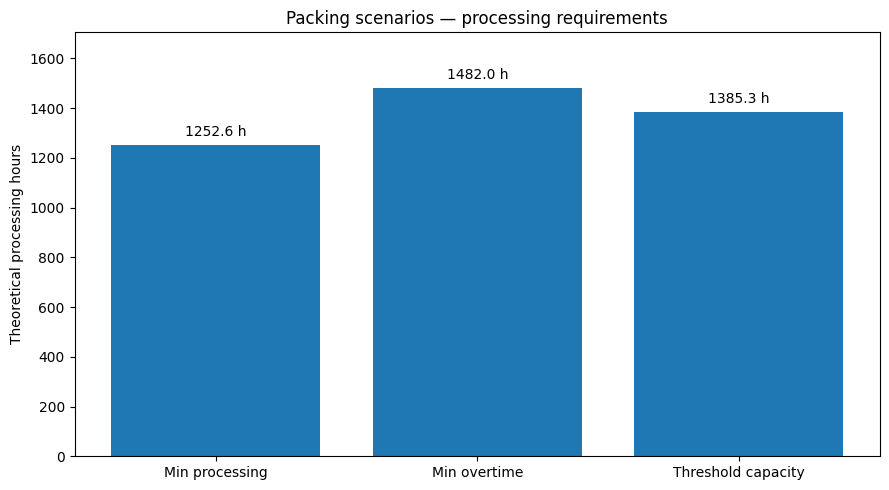

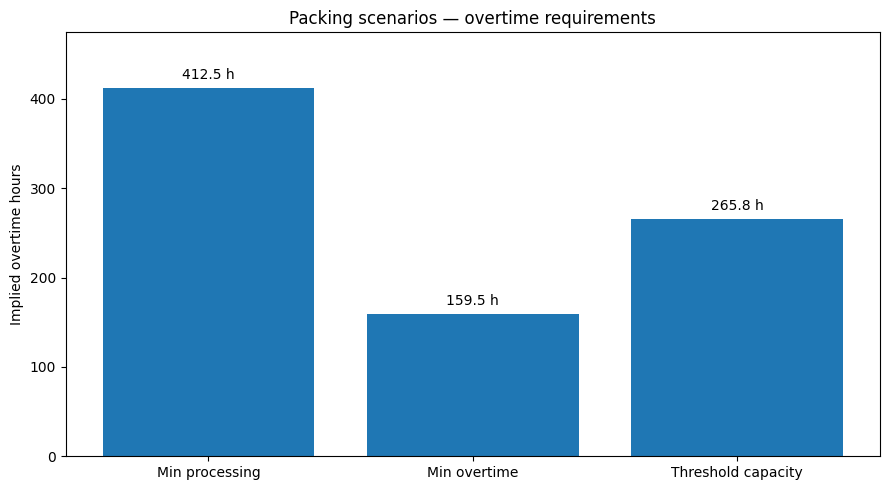

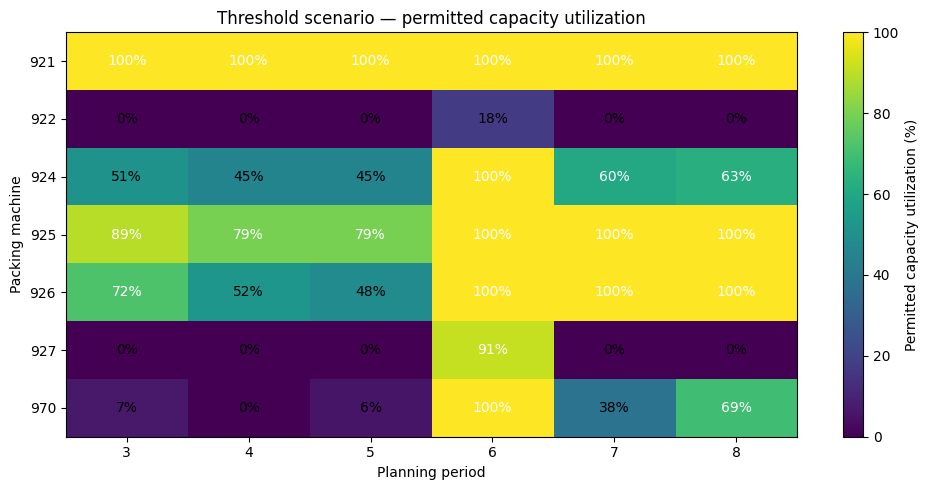


STEP 15 STATUS: PASS


In [0]:

# Project #4 — Python Analytics
# Step 15: Packing Scenario Visualizations
#
# Visualize three validated optimization scenarios.
# Figures represent modeled allocations, not actual
# packing activity or historical utilization.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Build the scenario comparison from saved results.

scenario_chart_data = pd.DataFrame({
    "scenario": [
        "Min processing",
        "Min overtime",
        "Threshold capacity"
    ],
    "processing_h": [
        processing_scenario["processing_h"].sum(),
        overtime_scenario["processing_h"].sum(),
        threshold_capacity_report["assigned_hours"].sum()
    ],
    "overtime_h": [
        processing_scenario["implied_overtime_h"].sum(),
        overtime_scenario["implied_overtime_h"].sum(),
        threshold_capacity_report["implied_overtime_h"].sum()
    ]
})

assert np.isclose(
    scenario_chart_data["processing_h"].iloc[0],
    packing_lp_result.fun,
    atol=0.01
)

assert np.isclose(
    scenario_chart_data["overtime_h"].iloc[1],
    minimum_overtime_result.fun,
    atol=0.01
)

assert np.isclose(
    scenario_chart_data["processing_h"].iloc[2],
    threshold_optimized.fun,
    atol=0.01
)

print("STEP 15 — SCENARIO VISUALIZATIONS")
print("=" * 75)
print(scenario_chart_data.round(2).to_string(index=False))

# 2. Processing-hours comparison.

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    scenario_chart_data["scenario"],
    scenario_chart_data["processing_h"]
)

ax.bar_label(bars, fmt="%.1f h", padding=4)
ax.set_ylabel("Theoretical processing hours")
ax.set_title("Packing scenarios — processing requirements")
ax.set_ylim(
    0,
    scenario_chart_data["processing_h"].max() * 1.15
)

plt.tight_layout()
plt.show()

# 3. Overtime comparison.

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    scenario_chart_data["scenario"],
    scenario_chart_data["overtime_h"]
)

ax.bar_label(bars, fmt="%.1f h", padding=4)
ax.set_ylabel("Implied overtime hours")
ax.set_title("Packing scenarios — overtime requirements")
ax.set_ylim(
    0,
    scenario_chart_data["overtime_h"].max() * 1.15
)

plt.tight_layout()
plt.show()

# 4. Threshold machine-period utilization heatmap.

heatmap_data = (
    active_period_report
    .pivot(
        index="packing_machine",
        columns="period",
        values="utilization_pct"
    )
    .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

heatmap = ax.imshow(
    heatmap_data.to_numpy(),
    aspect="auto",
    vmin=0,
    vmax=100
)

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

ax.set_xlabel("Planning period")
ax.set_ylabel("Packing machine")
ax.set_title(
    "Threshold scenario — permitted capacity utilization"
)

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]

        if pd.notna(value):
            ax.text(
                j, i, f"{value:.0f}%",
                ha="center",
                va="center",
                color="white" if value >= 60 else "black"
            )

fig.colorbar(
    heatmap,
    ax=ax,
    label="Permitted capacity utilization (%)"
)

plt.tight_layout()
plt.show()

print("\nSTEP 15 STATUS: PASS")


In [0]:

# Project #4 — Python Analytics
# Step 16: Prepare Power BI Scenario Tables
#
# Prepare three validated reporting datasets:
# 1. Scenario-level KPIs
# 2. Machine-period capacity and utilization
# 3. Product-period-machine allocations
#
# Read-only preparation. No Delta tables are written.

import numpy as np
import pandas as pd

SCENARIO_NAMES = [
    "Min processing",
    "Min overtime",
    "Threshold capacity"
]

# --------------------------------------------------
# 1. SCENARIO SUMMARY
# Grain: one row per optimization scenario
# --------------------------------------------------

# Rebuild the scenario summary directly from
# the validated optimization results.

scenario_summary = pd.DataFrame({
    "scenario": [
        "Min processing",
        "Min overtime",
        "Threshold capacity"
    ],
    "processing_h": [
        packing_lp_result.fun,
        minimum_overtime_final.fun,
        threshold_optimized.fun
    ],
    "overtime_h": [
        processing_scenario["implied_overtime_h"].sum(),
        overtime_scenario["implied_overtime_h"].sum(),
        threshold_capacity_report["implied_overtime_h"].sum()
    ]
})

scenario_summary["demand_allocated_m"] = float(
    b_eq.sum()
)

scenario_summary["overtime_pct_of_processing"] = (
    100
    * scenario_summary["overtime_h"]
    / scenario_summary["processing_h"]
)

scenario_summary["scenario_type"] = (
    "Modeled packing allocation"
)

# --------------------------------------------------
# 2. MACHINE-PERIOD CAPACITY
# Grain: scenario + packing machine + period
# --------------------------------------------------

standard_capacity = scenario_comparison[
    [
        "scenario",
        "packing_machine",
        "period",
        "processing_h",
        "implied_overtime_h",
        "available_total_hours"
    ]
].copy()

standard_capacity = standard_capacity.rename(
    columns={
        "available_total_hours": "capacity_limit_h"
    }
)

threshold_capacity_data = (
    threshold_capacity_report[
        [
            "packing_machine",
            "period",
            "assigned_hours",
            "implied_overtime_h",
            "permitted_hours"
        ]
    ]
    .copy()
    .rename(
        columns={
            "assigned_hours": "processing_h",
            "permitted_hours": "capacity_limit_h"
        }
    )
)

threshold_capacity_data["scenario"] = (
    "Threshold capacity"
)

machine_period_summary = pd.concat(
    [
        standard_capacity,
        threshold_capacity_data
    ],
    ignore_index=True
)

machine_period_summary["utilization_pct"] = np.where(
    machine_period_summary["capacity_limit_h"] > 0,
    100
    * machine_period_summary["processing_h"]
    / machine_period_summary["capacity_limit_h"],
    np.nan
)

machine_period_summary["remaining_capacity_h"] = (
    machine_period_summary["capacity_limit_h"]
    - machine_period_summary["processing_h"]
)

# --------------------------------------------------
# 3. PRODUCT ALLOCATION DETAILS
# Grain: scenario + product + period + packing machine
# Includes eligible routes with zero allocation.
# --------------------------------------------------

threshold_allocations = routes[
    [
        "product",
        "period",
        "packing_machine",
        "packing_time_sec_m"
    ]
].copy()

threshold_allocations["allocated_m"] = (
    threshold_optimized.x
)

allocation_columns = [
    "product",
    "period",
    "packing_machine",
    "packing_time_sec_m",
    "allocated_m"
]

allocation_tables = []

for scenario_name, source_df in [
    ("Min processing", routes),
    ("Min overtime", overtime_scenario_routes),
    ("Threshold capacity", threshold_allocations)
]:

    scenario_data = source_df[
        allocation_columns
    ].copy()

    scenario_data["scenario"] = scenario_name

    scenario_data["processing_h"] = (
        scenario_data["allocated_m"]
        * scenario_data["packing_time_sec_m"]
        / 3600.0
    )

    allocation_tables.append(scenario_data)

scenario_allocations = pd.concat(
    allocation_tables,
    ignore_index=True
)

scenario_allocations["is_active_allocation"] = (
    scenario_allocations["allocated_m"] > 0.000001
)

# --------------------------------------------------
# 4. DATA QUALITY AND RECONCILIATION
# --------------------------------------------------

assert len(scenario_summary) == 3
assert len(machine_period_summary) == 168
assert len(scenario_allocations) == 2106

assert not scenario_summary.duplicated(
    ["scenario"]
).any()

assert not machine_period_summary.duplicated(
    ["scenario", "packing_machine", "period"]
).any()

assert not scenario_allocations.duplicated(
    ["scenario", "product", "period", "packing_machine"]
).any()

assert set(scenario_summary["scenario"]) == set(
    SCENARIO_NAMES
)

for scenario_name in SCENARIO_NAMES:

    scenario_rows = scenario_allocations.loc[
        scenario_allocations["scenario"] == scenario_name
    ]

    assert len(scenario_rows) == 702

    # Check every product-period independently.
    assigned_by_demand = (
        scenario_rows
        .groupby(["product", "period"])["allocated_m"]
        .sum()
    )

    expected_by_demand = (
        demand_input
        .set_index(["product", "period"])[
            "adjusted_total_demand_m"
        ]
    )

    assert np.allclose(
        assigned_by_demand.reindex(
            expected_by_demand.index
        ).to_numpy(),
        expected_by_demand.to_numpy(),
        atol=0.01
    )

    # Reconcile processing hours to summary KPIs.
    detail_hours = scenario_rows["processing_h"].sum()

    summary_hours = scenario_summary.loc[
        scenario_summary["scenario"] == scenario_name,
        "processing_h"
    ].iloc[0]

    assert np.isclose(
        detail_hours,
        summary_hours,
        atol=0.01
    )

    # Reconcile machine-period overtime to KPIs.
    capacity_rows = machine_period_summary.loc[
        machine_period_summary["scenario"]
        == scenario_name
    ]

    summary_overtime = scenario_summary.loc[
        scenario_summary["scenario"] == scenario_name,
        "overtime_h"
    ].iloc[0]

    assert np.isclose(
        capacity_rows["implied_overtime_h"].sum(),
        summary_overtime,
        atol=0.01
    )

assert (
    machine_period_summary["remaining_capacity_h"]
    >= -0.0001
).all()

# --------------------------------------------------
# 5. REPORT RESULTS
# --------------------------------------------------

print("STEP 16 — POWER BI SCENARIO TABLES")
print("=" * 75)

print("Scenario summary rows:",
      len(scenario_summary))

print("Machine-period summary rows:",
      len(machine_period_summary))

print("Product allocation option rows:",
      len(scenario_allocations))

print("\nSCENARIO SUMMARY")

print(
    scenario_summary[
        [
            "scenario",
            "processing_h",
            "overtime_h",
            "demand_allocated_m",
            "overtime_pct_of_processing"
        ]
    ]
    .round(2)
    .to_string(index=False)
)

print("\nACTIVE ALLOCATIONS BY SCENARIO")

print(
    scenario_allocations
    .groupby("scenario")["is_active_allocation"]
    .sum()
    .to_string()
)

print("\nDATA QUALITY")
print("Unique scenario keys: PASS")
print("Unique machine-period keys: PASS")
print("Unique allocation keys: PASS")
print("Product-period demand reconciliation: PASS")
print("Processing-hour reconciliation: PASS")
print("Overtime reconciliation: PASS")
print("Capacity validation: PASS")

print("\nSTEP 16 STATUS: PASS")


STEP 16 — POWER BI SCENARIO TABLES
Scenario summary rows: 3
Machine-period summary rows: 168
Product allocation option rows: 2106

SCENARIO SUMMARY
          scenario  processing_h  overtime_h  demand_allocated_m  overtime_pct_of_processing
    Min processing       1252.59      412.53           3071692.0                       32.93
      Min overtime       1482.02      159.48           3071692.0                       10.76
Threshold capacity       1385.33      265.76           3071692.0                       19.18

ACTIVE ALLOCATIONS BY SCENARIO
scenario
Min overtime          270
Min processing        252
Threshold capacity    260

DATA QUALITY
Unique scenario keys: PASS
Unique machine-period keys: PASS
Unique allocation keys: PASS
Product-period demand reconciliation: PASS
Processing-hour reconciliation: PASS
Overtime reconciliation: PASS
Capacity validation: PASS

STEP 16 STATUS: PASS


In [0]:

# STEP 17A — Prepare Delta reporting tables

import pandas as pd
import numpy as np

catalog = "workspace"
schema = "scenario_sop"

required = [
    "scenario_summary",
    "machine_period_summary",
    "scenario_allocations"
]

missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "Run Step 16 first. Missing: " + ", ".join(missing)
    )

assert len(scenario_summary) == 3
assert len(machine_period_summary) == 168
assert len(scenario_allocations) == 2106

spark.sql(
    f"CREATE SCHEMA IF NOT EXISTS {catalog}.{schema}"
)

# Reporting copies; original Step 16 DataFrames remain unchanged.
summary_out = scenario_summary.copy()
machine_out = machine_period_summary.copy()
allocations_out = scenario_allocations.copy()

# Preserve product identifiers as text, not measurements.
allocations_out["product"] = (
    allocations_out["product"].astype(str)
)
allocations_out["packing_machine"] = (
    allocations_out["packing_machine"].astype(str)
)
machine_out["packing_machine"] = (
    machine_out["packing_machine"].astype(str)
)

# Ensure consistent reporting types.
machine_out["period"] = machine_out["period"].astype(int)
allocations_out["period"] = allocations_out["period"].astype(int)

# Describe the assumptions behind each scenario.
scenario_assumptions = pd.DataFrame([
    {
        "scenario": "Min processing",
        "objective": "Minimize total packing processing hours",
        "capacity_rule": "Regular plus full available overtime",
        "overtime_fraction": 1.0
    },
    {
        "scenario": "Min overtime",
        "objective": "Minimize implied overtime, then processing hours",
        "capacity_rule": "Regular plus full available overtime",
        "overtime_fraction": 1.0
    },
    {
        "scenario": "Threshold capacity",
        "objective": "Minimize processing hours at the tested feasible overtime threshold",
        "capacity_rule": "Regular plus a uniform fraction of available overtime",
        "overtime_fraction": float(threshold_fraction)
    }
])

scenario_assumptions["model_scope"] = (
    "Theoretical packing allocation; not an executed schedule"
)

scenario_assumptions["planning_assumptions"] = (
    "Same-period demand allocation; eligible source packing "
    "routes; source machine-period capacity; no inventory "
    "carryover or actual production execution modeled"
)

assert len(scenario_assumptions) == 3

print("STEP 17A — PASS")
print("Target schema:", f"{catalog}.{schema}")
print("Threshold allowance:",
      f"{threshold_fraction * 100:.3f}%")
print("Reporting datasets and assumptions prepared.")


STEP 17A — PASS
Target schema: workspace.scenario_sop
Threshold allowance: 27.344%
Reporting datasets and assumptions prepared.


In [0]:

# STEP 17B — Persist scenario analytics to Delta
# Overwrites only these four tables in workspace.scenario_sop.

tables_to_write = {
    "scenario_summary": summary_out,
    "machine_period_summary": machine_out,
    "scenario_allocations": allocations_out,
    "scenario_assumptions": scenario_assumptions
}

for table_name, pandas_df in tables_to_write.items():

    full_name = f"{catalog}.{schema}.{table_name}"

    spark_df = spark.createDataFrame(
        pandas_df.reset_index(drop=True)
    )

    (
        spark_df.write
        .format("delta")
        .mode("overwrite")
        .option("overwriteSchema", "true")
        .saveAsTable(full_name)
    )

    print(
        f"WRITTEN: {full_name} "
        f"({spark.table(full_name).count():,} rows)"
    )

print("\nSTEP 17B — DELTA WRITES COMPLETE")


WRITTEN: workspace.scenario_sop.scenario_summary (3 rows)
WRITTEN: workspace.scenario_sop.machine_period_summary (168 rows)
WRITTEN: workspace.scenario_sop.scenario_allocations (2,106 rows)
WRITTEN: workspace.scenario_sop.scenario_assumptions (3 rows)

STEP 17B — DELTA WRITES COMPLETE


In [0]:

# STEP 17C — Validate persisted Delta tables

from pyspark.sql import functions as F

expected_counts = {
    "scenario_summary": 3,
    "machine_period_summary": 168,
    "scenario_allocations": 2106,
    "scenario_assumptions": 3
}

for name, expected in expected_counts.items():
    actual = spark.table(
        f"{catalog}.{schema}.{name}"
    ).count()

    assert actual == expected, (
        f"{name}: expected {expected}, found {actual}"
    )

    print(f"{name}: {actual:,} rows — PASS")

saved_summary = spark.table(
    f"{catalog}.{schema}.scenario_summary"
).toPandas()

saved_machine = spark.table(
    f"{catalog}.{schema}.machine_period_summary"
)

saved_allocations = spark.table(
    f"{catalog}.{schema}.scenario_allocations"
)

# Check uniqueness at each reporting grain.
assert saved_machine.groupBy(
    "scenario", "packing_machine", "period"
).count().filter(F.col("count") > 1).count() == 0

assert saved_allocations.groupBy(
    "scenario", "product", "period", "packing_machine"
).count().filter(F.col("count") > 1).count() == 0

# Compare saved scenario KPIs with validated Step 16 KPIs.
expected = scenario_summary.set_index("scenario")
actual = saved_summary.set_index("scenario")

for name in expected.index:
    for metric in [
        "processing_h",
        "overtime_h",
        "demand_allocated_m"
    ]:
        assert np.isclose(
            actual.loc[name, metric],
            expected.loc[name, metric],
            atol=0.01
        ), f"Mismatch: {name} / {metric}"

# Reconcile saved allocations against saved summary.
allocation_totals = (
    saved_allocations
    .groupBy("scenario")
    .agg(
        F.sum("allocated_m").alias("total_allocated_m"),
        F.sum("processing_h").alias("total_processing_h")
    )
    .toPandas()
    .set_index("scenario")
)

for name in expected.index:
    assert np.isclose(
        allocation_totals.loc[name, "total_allocated_m"],
        actual.loc[name, "demand_allocated_m"],
        atol=0.01
    )
    assert np.isclose(
        allocation_totals.loc[name, "total_processing_h"],
        actual.loc[name, "processing_h"],
        atol=0.01
    )

print("\nDuplicate-key checks: PASS")
print("Saved KPI reconciliation: PASS")
print("Saved allocation reconciliation: PASS")
print("\nSTEP 17 STATUS: PASS")


scenario_summary: 3 rows — PASS
machine_period_summary: 168 rows — PASS
scenario_allocations: 2,106 rows — PASS
scenario_assumptions: 3 rows — PASS

Duplicate-key checks: PASS
Saved KPI reconciliation: PASS
Saved allocation reconciliation: PASS

STEP 17 STATUS: PASS
